# Hands-on 1: a small support chatbot
**Student notebook | Llama 3.2 1B through local Ollama**

A user types a request in a text field and presses **Send**. The chatbot can:

| Request | Expected reply source |
|---|---|
| `Track ORD-1001` | SQLite says the parcel is **shipped** |
| `Track ORD-1002` | SQLite says the parcel is **processing** |
| `How long does delivery take?` | The stored policy: **3-5 working days** |
| `How can I contact support?` | The stored contact: **support@example.com** |
| `What is a Python list?` | A short answer generated by the model |

You have **three tasks**: **A** write a prompt, **B** parse the model output,
and **C** call a service when needed. The data loader, two helpers and UI are supplied.
All order records are fictional. This chatbot cannot change or refund an order.

### Conversation rule: one complete request at a time
Each submission starts fresh. No previous message or order ID is remembered.
If the reply asks for an ID, resend **`Track ORD-1001`** rather than only the ID.

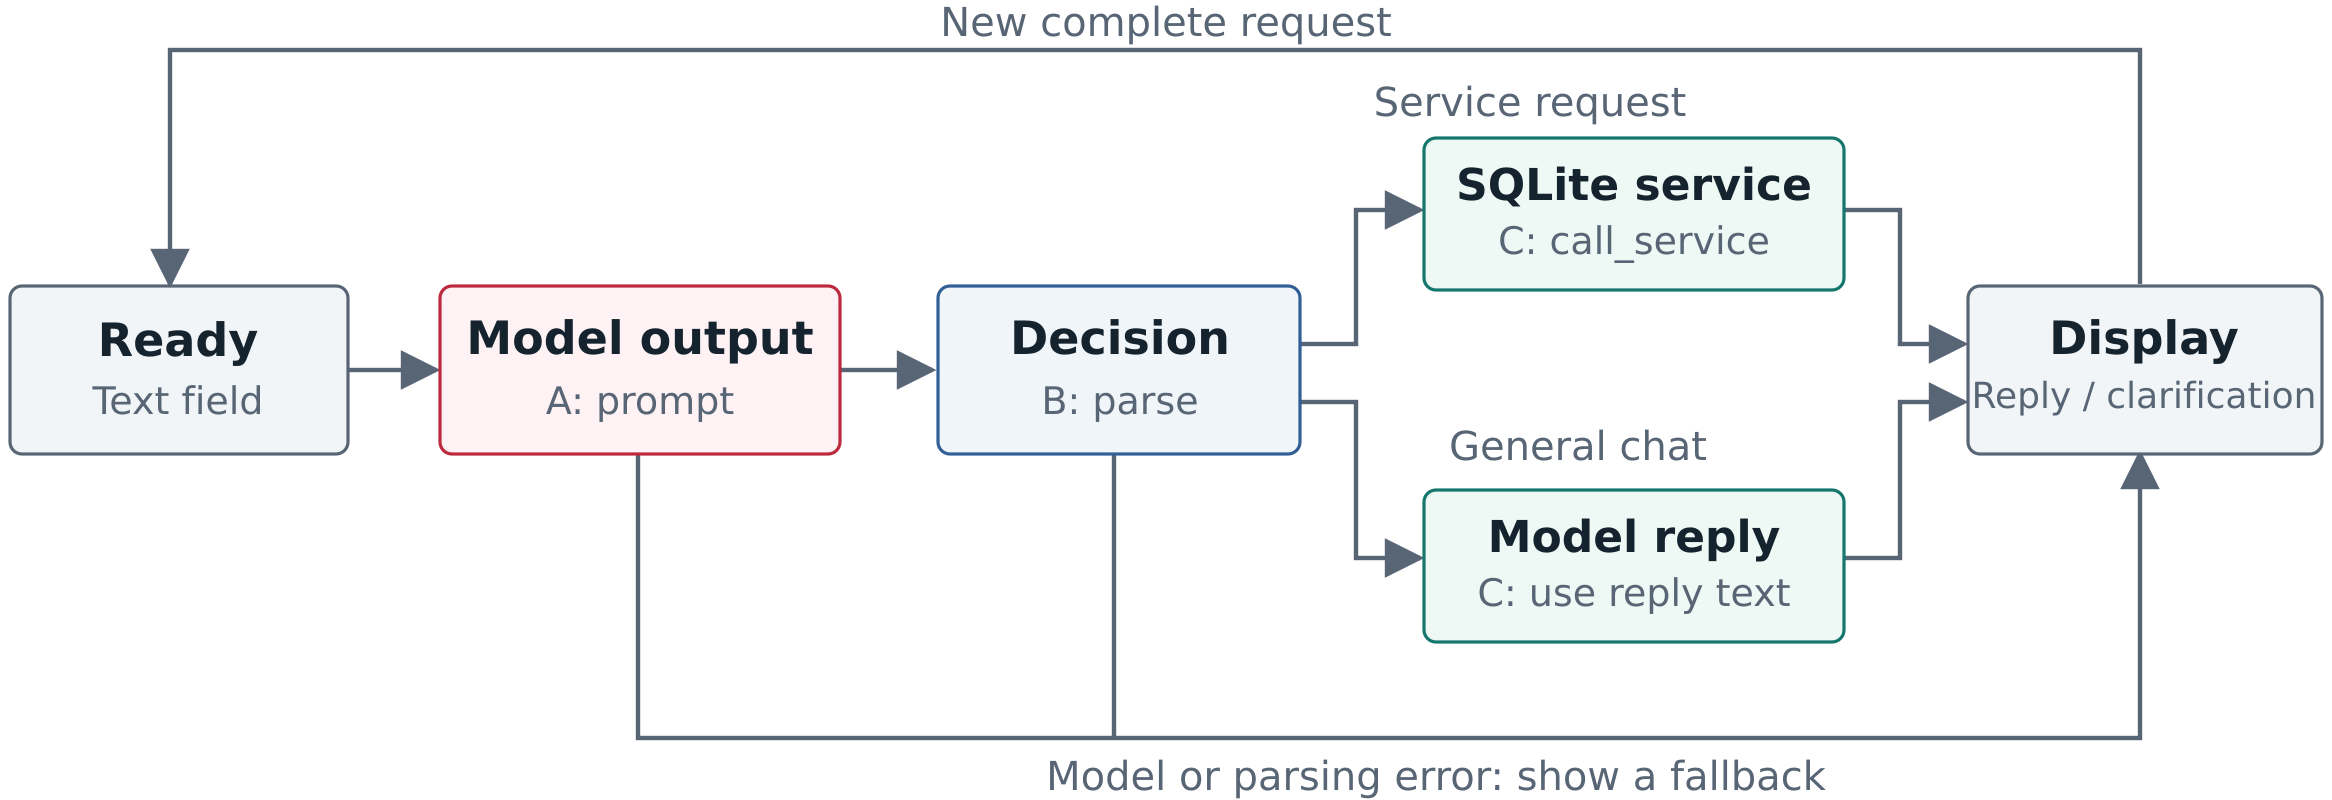

The model makes one decision. Python validates it, chooses a reply source and stops.
This is a fixed workflow. A later version could retain conversation state.

### Before you start
Extract the ZIP and launch Jupyter from that folder. Use your existing course setup:
Python, Jupyter, `ipywidgets`, and Ollama with the exact model **`llama3.2:1b`**.
The previous kickoff still prepares these prerequisites. If needed, use a terminal:
`python -m pip install jupyterlab ipywidgets`, then `ollama pull llama3.2:1b`.
Open Ollama before trying a live request. No paid API or GPU is needed.

Run in order. The student edition intentionally stops at each unfinished task check.
The completed edition can run all cells without contacting Ollama until you enable
the optional prompt test or press **Send**. Keep this in its own folder: Part 1
rebuilds the two tables in the local **demo** database from the JSON files.


## Part 1: load data 
`data.json` is the editable source. This block loads every `data*.json` file into
SQLite: `orders(order_id, status)` and `info(name, text)`.

To add parcels, edit `data.json` or add `data_extra.json` beside it, for example:
```json
{"orders": [{"order_id": "ORD-1004", "status": "processing"}]}
```
**Rerun this block** after editing files. It rebuilds both demo tables, so removed
records disappear too. Files load in filename order; a later file replaces a row
with the same ID or information name. The printed rows show what the chatbot can read.


In [3]:
import json, re, sqlite3
from pathlib import Path
from urllib import request

ROOT = Path.cwd()
data_files = sorted(ROOT.glob("data*.json"))
assert ROOT / "data.json" in data_files, "Extract the pack and open Jupyter in its folder."
if "db" in globals():
    db.close()
db = sqlite3.connect(ROOT / "support.sqlite3")
with db:
    db.execute("CREATE TABLE IF NOT EXISTS orders (order_id TEXT PRIMARY KEY, status TEXT)")
    db.execute("CREATE TABLE IF NOT EXISTS info (name TEXT PRIMARY KEY, text TEXT)")
    # Rebuild these demo tables from the files on every run.
    db.execute("DELETE FROM orders")
    db.execute("DELETE FROM info")
    for path in data_files:
        data = json.loads(path.read_text(encoding="utf-8"))
        db.executemany("INSERT OR REPLACE INTO orders VALUES (?, ?)",
                       [(row["order_id"], row["status"]) for row in data.get("orders", [])])
        db.executemany("INSERT OR REPLACE INTO info VALUES (?, ?)", data.get("info", {}).items())
print("Loaded files:", [p.name for p in data_files])
print("Orders:", db.execute("SELECT * FROM orders ORDER BY order_id").fetchall())
print("Information:", db.execute("SELECT * FROM info ORDER BY name").fetchall())


Loaded files: ['data.json']
Orders: [('ORD-1001', 'shipped'), ('ORD-1002', 'processing'), ('ORD-1003', 'delivered')]
Information: [('contact_support', 'For further support, email support@example.com.'), ('delivery_info', 'Delivery normally takes 3-5 working days.')]


## Part 2: Helper Functions
Run this block unchanged. You can call these functions in your tasks:

| Function | Input | Return value |
|---|---|---|
| `ask_model(user_text)` | Current request; uses `SYSTEM_PROMPT` from Task A | Raw JSON text from Ollama |
| `call_service(intent, user_text)` | Service label and original request | Reply text read from SQLite, or a clarification |
| `json.loads(raw)` (Python standard library) | JSON text | A Python value; invalid JSON raises `ValueError` |

`call_service` supports `order_status`, `delivery_info` and `contact_support`.
It already handles missing IDs, several IDs and unknown orders. It finds an ID only
when the user supplies `ORD-` followed by four digits. No SQL is required from you.

`ask_model` sends two messages: the prompt and the current request. JSON mode asks
for JSON, but your parser must still check its fields. Its CPU setting is
`num_gpu=0`. The 120-second socket timeout is not a latency target.


In [ ]:
OUTPUT_SCHEMA = {
    "oneOf": [
        {
            # Service requests: the application supplies the reply.
            "type": "object",
            "properties": {
                "intent": {
                    "type": "string",
                    "enum": [
                        "order_status",
                        "delivery_info",
                        "contact_support"
                    ]
                }
            },
            "required": ["intent"],
            "additionalProperties": False
        },
        {
            # General chat: the model supplies the reply.
            "type": "object",
            "properties": {
                "intent": {
                    "type": "string",
                    "enum": ["chat"]
                },
                "reply": {
                    "type": "string",
                    "minLength": 1
                }
            },
            "required": ["intent", "reply"],
            "additionalProperties": False
        }
    ]
}

In [2]:
MODEL = "llama3.2:1b"
BASE_URL = "http://127.0.0.1:11434"
INTENTS = ["order_status", "delivery_info", "contact_support", "chat"]

def ask_model(user_text):
    """Send this request and Task A's prompt to Ollama. Return raw JSON text."""
    payload = {"model": MODEL, "stream": False, "format": OUTPUT_SCHEMA,
               "messages": [{"role": "system", "content": SYSTEM_PROMPT},
                            {"role": "user", "content": user_text}],
               "options": {"temperature": 0, "num_ctx": 2048, "num_predict": 192, "num_gpu": 0}}
    req = request.Request(BASE_URL + "/api/chat", data=json.dumps(payload).encode("utf-8"),
                          headers={"Content-Type": "application/json"})
    with request.urlopen(req, timeout=120) as response:
        result = json.load(response)
    if result.get("done") is not True or result.get("done_reason") == "length":
        raise ValueError("The model response is incomplete. Check Ollama and the output limit.")
    return result["message"]["content"]

def call_service(intent, user_text=""):
    """Read SQLite and return reply text. The model cannot change these records."""
    if intent == "order_status":
        ids = list(dict.fromkeys(re.findall(r"(?<![A-Za-z0-9_])ORD-[0-9]{4}(?![A-Za-z0-9_])", user_text)))
        if not ids:
            return "Please resend a complete request with an ID, such as: Track ORD-1001."
        if len(ids) > 1:
            return "Please ask about one order at a time."
        row = db.execute("SELECT status FROM orders WHERE order_id = ?", (ids[0],)).fetchone()
        return f"Order {ids[0]} is {row[0]}." if row else "I could not find that order. Please ask for support contact details."
    if intent not in {"delivery_info", "contact_support"}:
        raise ValueError("Unknown service.")
    row = db.execute("SELECT text FROM info WHERE name = ?", (intent,)).fetchone()
    return row[0] if row else "This information is unavailable in the demo data."

print("Two helpers ready: ask_model and call_service.")


Two helpers ready: ask_model and call_service.


## Task A: write the prompt
Edit **`prompt_student.txt`**, then rerun the prompt-loading block below.

| Intent | When to select it | Model output |
|---|---|---|
| `order_status` | A particular parcel, even when its ID is missing | `{"intent":"order_status"}` |
| `delivery_info` | General delivery policy or duration | `{"intent":"delivery_info"}` |
| `contact_support` | Contact a person, or request a change/refund this demo cannot perform | `{"intent":"contact_support"}` |
| `chat` | Greeting or an unrelated question | `{"intent":"chat","reply":"A short answer"}` |

Define the labels and add examples. Require JSON only. A service response contains
only `intent`; the service will supply the facts. A chat response also contains a
non-empty `reply`. Ask the model to give short general answers and acknowledge what
it does not know. For several service requests in one message, ask for one at a time.


In [ ]:
SYSTEM_PROMPT = (ROOT / "prompt_student.txt").read_text(encoding="utf-8")


In [ ]:
# Check that you have replaced the starter instructions.
assert SYSTEM_PROMPT.strip() and "TODO" not in SYSTEM_PROMPT
print("Prompt loaded. Inspect the text and examples in your prompt file.")

RUN_PROMPT_TEST = False  # Set True when Ollama is ready. This makes one real model call.
if RUN_PROMPT_TEST:
    raw = ask_model("How many days does delivery normally take?")
    print("Model output:", raw)
    assert json.loads(raw).get("intent") == "delivery_info"
    print("This request selected the right intent. Try other wording as well.")
else:
    print("Live prompt test skipped. Loading a prompt does not prove its quality.")


## Task B: parse and check the output
Implement **`parse_output(raw)`**. It receives text and returns a Python dictionary.

1. Parse the text with `json.loads`.
2. Check that the result is a dictionary with an `intent` in `INTENTS`.
3. A service decision must have exactly the `intent` key. A chat decision must have
   exactly `intent` and `reply`, with a non-empty text reply.
4. Raise `ValueError` for invalid output; otherwise return the dictionary.

The eight checks below use recorded strings, so they do not need a running model.
A valid label can still be the wrong interpretation of the user's request.


In [ ]:
def parse_output(raw):
    # TODO B: use json.loads(raw), check the Task B contract, then return the dictionary.
    # Raise ValueError for invalid output. json.loads already rejects invalid JSON.
    raise NotImplementedError("Complete Task B: parse and check the output.")


In [ ]:
# Two valid responses.
assert parse_output('{"intent":"order_status"}') == {"intent": "order_status"}
assert parse_output('{"intent":"chat","reply":"Hello!"}')["reply"] == "Hello!"

# Six invalid responses: every one must raise ValueError.
bad_outputs = [
    'not JSON', '{"intent":"refund"}', '{"intent":"chat"}',
    '{"intent":"chat","reply":7}', '{"intent":"chat","reply":""}',
    '{"intent":"order_status","reply":"Your order is delivered."}',
]
for raw in bad_outputs:
    try:
        parse_output(raw)
    except ValueError:
        continue
    raise AssertionError(f"Should reject: {raw}")
print("Task B: 8 parser checks passed. No model ran.")


## Task C: Build the reply and connect the workflow

Your final task is to connect the model, your parser, and the provided services
to the chatbot interface.

For each submitted request, the application follows this sequence:

**User request → Model output → Validated decision → Reply or service call → Display**

### C1. Implement `make_reply(decision, user_text)`

The `decision` dictionary has already passed the validation in Task B.

- If the intent is `chat`, return the reply contained in the dictionary.
- For `order_status`, `delivery_info`, or `contact_support`, call the provided
  `call_service(intent, user_text)` and return its result.

Pass the original `user_text` to the service so it can find an order ID.
The service already handles missing or unknown IDs and reads information
from SQLite. You do not need to write SQL or extract the ID yourself.

Your function must return a string. It should not print or call the model again.



In [ ]:
def make_reply(decision, user_text):
    """Return one reply string from a validated decision."""

    # TODO C1:
    # - For chat, return the reply in decision.
    # - For a service intent, call the provided service and return its result.
    #   Pass both the intent and the original user_text.

    raise NotImplementedError("Complete Task C1: choose the reply source.")

### C2. Complete the request-processing sequence

In the provided UI code, complete the TODO inside `send_request`.

1. Call the model with the user's request and store its raw output.
2. Pass that output to your Task B parser.
3. Pass the validated decision and original request to `make_reply`.

The supplied code displays the reply and catches errors. If an earlier step
fails, the remaining steps should not run.

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# Provided: create the interface.
text_box = widgets.Textarea(
    value="Track ORD-1001",
    description="Request:",
    layout=widgets.Layout(width="95%")
)
send_button = widgets.Button(
    description="Send",
    button_style="primary"
)
output = widgets.Output()


def send_request(button):
    user_text = text_box.value.strip()

    with output:
        output.clear_output(wait=True)

        if not user_text:
            print("Please type a request.")
            return

        send_button.disabled = True

        try:
            # TODO C2: replace the NotImplementedError below with:
            # 1. A model call; store its output in raw.
            # 2. A parser call; store its result in decision.
            # 3. A make_reply call; store its result in reply.

            raise NotImplementedError("Complete Task C2: connect the workflow.")

            # Provided: display the final reply.
            print("Assistant:", reply)

        except (ValueError, OSError, KeyError, TypeError, RuntimeError) as exc:
            print("I could not process that request. Please try again.")
            print("For debugging:", exc)

        finally:
            send_button.disabled = False


# Provided: connect the button and display the interface.
send_button.on_click(send_request)
display(text_box, send_button, output)

## Finish
**Done:** Task A's prompt is complete, all 16 recorded checks in B and C pass, and
you have tried the live UI. An unavailable model should be recorded as untested.

Add `ORD-1004` in `data_extra.json`, rerun Part 1 and ask for its status. You do not
need to change a helper or Task C. Retain the supplied records to keep the base tests valid.

Discuss one example where the model chose the wrong intent. Did the parser catch it?
What state would you have to retain to accept only an ID as a follow-up?
Which replies came from SQLite, and which depended on the model's knowledge?

This is a teaching prototype. A correct JSON shape does not guarantee correct routing
or a correct general answer. The next lecture can add conversation state and richer evidence.

References for the supplied caller: [Ollama chat API](https://docs.ollama.com/api/chat),
[JSON output](https://docs.ollama.com/capabilities/structured-outputs),
[Llama 3.2 1B](https://ollama.com/library/llama3.2:1b).
